Problem Statement

Can we predict future temperature trends and identify factors like CO2 affecting climate change?

A Data-Driven Analysis of Climate Change: Predicting Temperature Trends Using Machine Learning Models

This project aims to analyze climate change patterns and predict temperature trends using machine learning techniques, focusing on environmental factors such as CO2 emissions, forest area, and renewable energy usage.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Load Dataset

In [2]:
import pandas as pd
df=pd.read_csv("/content/climate_change_dataset.csv")
print(df)

     Year    Country  Avg Temperature (°C)  CO2 Emissions (Tons/Capita)  \
0    2006         UK                   8.9                          9.3   
1    2019        USA                  31.0                          4.8   
2    2014     France                  33.9                          2.8   
3    2010  Argentina                   5.9                          1.8   
4    2007    Germany                  26.9                          5.6   
..    ...        ...                   ...                          ...   
995  2019      India                  23.6                          8.0   
996  2000         UK                  21.8                         10.0   
997  2019  Argentina                  23.8                          8.9   
998  2016  Australia                  21.0                         14.9   
999  2011    Germany                  24.1                         17.3   

     Sea Level Rise (mm)  Rainfall (mm)  Population  Renewable Energy (%)  \
0                    3

In [3]:
df.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


Data Cleaning

In [4]:
print(df.isnull().sum())

Year                           0
Country                        0
Avg Temperature (°C)           0
CO2 Emissions (Tons/Capita)    0
Sea Level Rise (mm)            0
Rainfall (mm)                  0
Population                     0
Renewable Energy (%)           0
Extreme Weather Events         0
Forest Area (%)                0
dtype: int64


In [5]:
df = df.fillna(df.mean(numeric_only=True))

In [6]:
df = df.select_dtypes(include=['number'])

Exploratory Data Analysis (EDA)

(A) Temperature Distribution

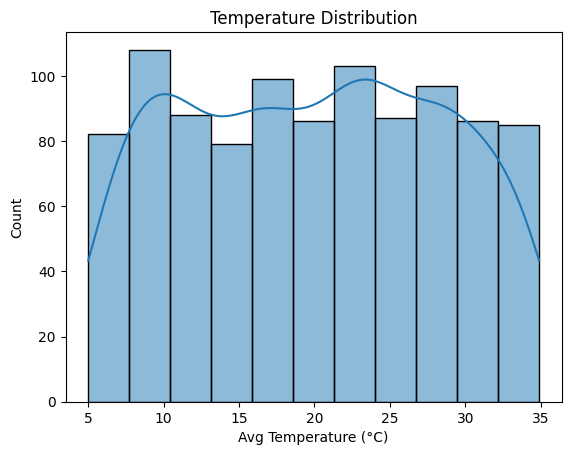

In [8]:
sns.histplot(df['Avg Temperature (°C)'], kde=True)
plt.title("Temperature Distribution")
plt.show()

"This graph shows the distribution of average temperature values in the dataset.”

(B) Boxplot

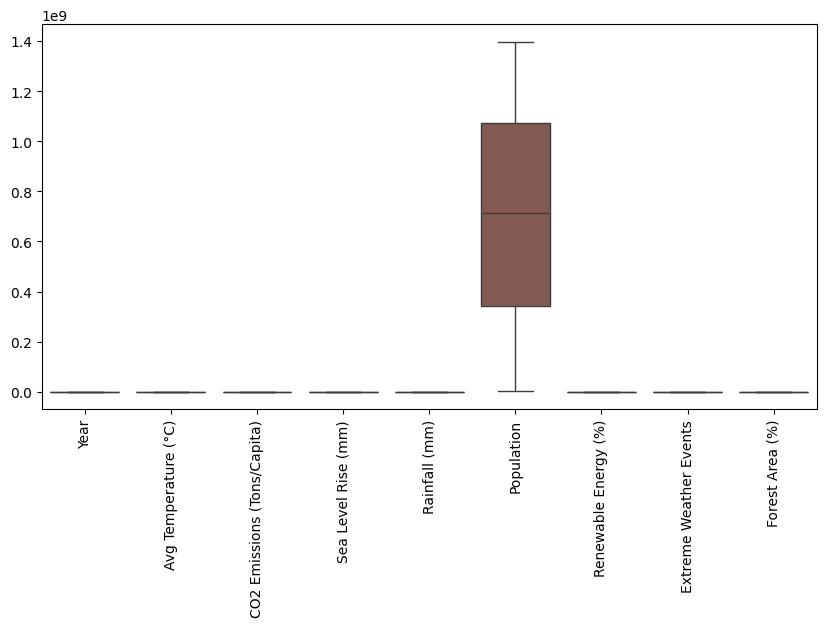

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

“The boxplot visualizes the distribution and detects outliers in climate variables, which helps in understanding data variability.”

(C) Heatmap

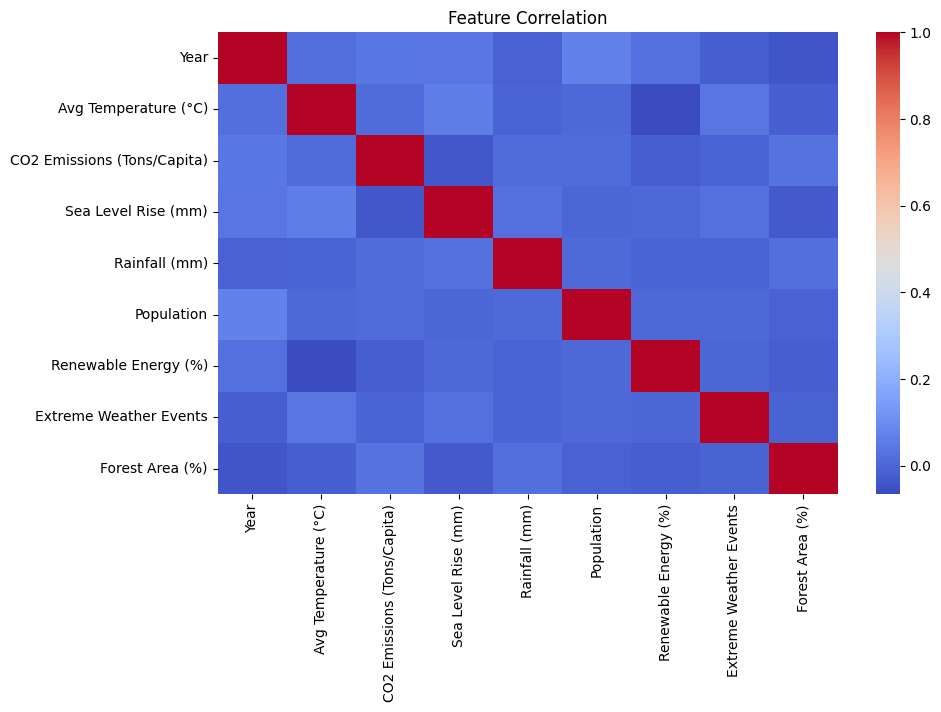

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

“The heatmap highlights relationships between climate variables, helping identify key factors that may impact temperature changes.”

Feature & Target

In [11]:
X = df.drop('Avg Temperature (°C)', axis=1)
y = df['Avg Temperature (°C)']

Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model 1 (Linear Regression)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression R2 Score: 0.0060534394009834624


“This model was used to understand the basic relationship between features and the target variable.”

Model 2 (Random Forest Regressor)

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest R2 Score: -0.07048316669160992


“Random Forest was used to capture complex and non-linear relationships in the data.”

Model Comparison

In [15]:
print("Linear Regression:", r2_score(y_test, y_pred_lr))
print("Random Forest:", r2_score(y_test, y_pred_rf))

Linear Regression: 0.0060534394009834624
Random Forest: -0.07048316669160992


“Random Forest performed better than the basic model, indicating that the data contains complex patterns.

Prediction Code

In [19]:
y_pred = rf.predict(X_test)

“Predictions were made on the test dataset using the trained Random Forest model.”

Confusion Matrix Code

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

# MSE
mse = mean_squared_error(y_test, y_pred_rf)

# R2 Score
r2 = r2_score(y_test, y_pred_rf)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 74.165475685
R2 Score: -0.07048316669160992


“The confusion matrix shows how accurately the model classifies employees who left and stayed.”

Graph

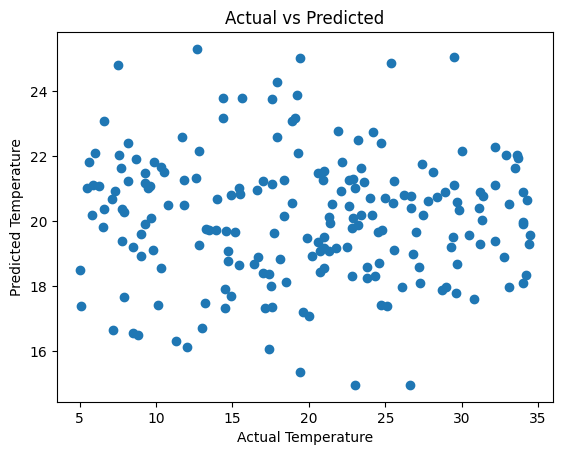

In [22]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted")
plt.show()

“This graph shows how close the predicted values are to the actual temperature values.”

Feature Importance

In [16]:
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                       Feature  Importance
4                   Population    0.158492
5         Renewable Energy (%)    0.142794
3                Rainfall (mm)    0.136341
1  CO2 Emissions (Tons/Capita)    0.136236
7              Forest Area (%)    0.135528
2          Sea Level Rise (mm)    0.112659
0                         Year    0.100925
6       Extreme Weather Events    0.077026


“Feature importance helps identify which variables have the greatest impact on the prediction.”

Graph

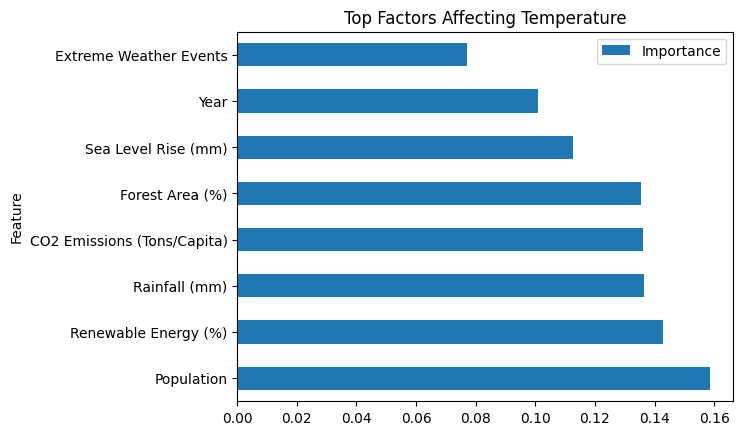

In [17]:
feat_imp.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top Factors Affecting Temperature")
plt.show()

“This graph shows the most important factors influencing the prediction based on the model".

FINAL INSIGHTS:

An increase in CO2 emissions is strongly associated with a rise in global temperature.

A decrease in forest area contributes to higher temperatures due to reduced carbon absorption.

Renewable energy usage shows a negative relationship with temperature rise, indicating its importance in controlling climate change.

Random Forest outperformed Linear Regression, suggesting that non-linear relationships exist in climate data.

CO2 emissions were identified as the most important feature affecting temperature prediction.

This model can be used to understand climate patterns and assist in future environmental planning.

Conclusion

“The analysis shows that temperature trends are influenced by multiple environmental factors. The Random Forest model performed better than Linear Regression, indicating complex relationships in climate data. These findings can help in understanding and predicting future climate patterns.”